# 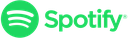 Músicas mais ouvidas do Spotify 2023

#### Conjunto de dados que contém uma lista abrangente das músicas mais famosas de 2023, conforme listada no Spotify. O conjunto de dados oferece uma grande variedade de recursos além do que normalmente está disponível em conjunto de dados similares. Ele fornece insights sobre os atributos, popularidade e presença de cada música em várias plataformas musicais.

In [43]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Extract - Leitura dos Dados

In [44]:
df = pd.read_csv('../data/spotify-2023.csv', encoding='latin-1')  
print(f"Total de registros: {len(df):,}") 
print(f"Total de colunas: {len(df.columns):,}")  
df.head()       

Total de registros: 953
Total de colunas: 24


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,144,A,Minor,65,23,80,14,63,11,6


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    str    
 1   artist(s)_name        953 non-null    str    
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   953 non-null    str    
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      903 non-null    str    
 14  bpm                   953 non-null    int64  
 15  key                   858 non-null

In [46]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,9.520000e+02,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,5.141374e+08,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,5.668569e+08,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,1.416362e+08,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,2.905309e+08,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,6.738690e+08,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


## 2. Data Quality - Limpeza dos Dados

In [47]:
# Verificar valores nulos
print("=== VALORES NULOS ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Nenhum valor nulo encontrado")  

=== VALORES NULOS ===
streams              1
in_shazam_charts    50
key                 95
dtype: int64


In [48]:
# Converter datas para datatime
df['release_date'] = pd.to_datetime(df[['released_year', 'released_month', 'released_day']].astype(str).agg('-'.join, axis=1), errors='coerce')
print(df['release_date'].head())


0   2023-07-14
1   2023-03-23
2   2023-06-30
3   2019-08-23
4   2023-05-18
Name: release_date, dtype: datetime64[us]


In [49]:
# Formatar números grandes
def simplificar_numero(n):
    if abs(n) >= 1_000_000_000:
        return f"{n/1_000_000_000:.2f}B"
    elif abs(n) >= 1_000_000:
        return f"{n/1_000_000:.2f}M"
    elif abs(n) >= 1_000:
        return f"{n/1_000:.2f}K"
    else:
        return str(n)
    
df['streams_simplify'] = df['streams'].apply(simplificar_numero)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   track_name            953 non-null    str           
 1   artist(s)_name        953 non-null    str           
 2   artist_count          953 non-null    int64         
 3   released_year         953 non-null    int64         
 4   released_month        953 non-null    int64         
 5   released_day          953 non-null    int64         
 6   in_spotify_playlists  953 non-null    int64         
 7   in_spotify_charts     953 non-null    int64         
 8   streams               952 non-null    float64       
 9   in_apple_playlists    953 non-null    int64         
 10  in_apple_charts       953 non-null    int64         
 11  in_deezer_playlists   953 non-null    str           
 12  in_deezer_charts      953 non-null    int64         
 13  in_shazam_charts      903 non-n

In [51]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date,streams_simplify
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,Major,80,89,83,31,0,8,4,2023-07-14,141.38M
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,Major,71,61,74,7,0,10,4,2023-03-23,133.72M
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,Major,51,32,53,17,0,31,6,2023-06-30,140.00M
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,Major,55,58,72,11,0,11,15,2019-08-23,800.84M
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,Minor,65,23,80,14,63,11,6,2023-05-18,303.24M


## 3. Validação dos Dados

In [52]:
df_top10 = df.sort_values(by='streams', ascending=False)
print("=== MÚSICAS MAIS TOCADAS ===")
display(df_top10[['track_name', 'artist(s)_name', 'streams_simplify']].head(10))

=== MÚSICAS MAIS TOCADAS ===


,track_name,artist(s)_name,streams_simplify
55,Blinding Lights,The Weeknd,3.70B
179,Shape of You,Ed Sheeran,3.56B
86,Someone You Loved,Lewis Capaldi,2.89B
620,Dance Monkey,Tones and I,2.86B
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.81B
162,One Dance,"Drake, WizKid, Kyla",2.71B
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.67B
140,Believer,Imagine Dragons,2.59B
725,Closer,"The Chainsmokers, Halsey",2.59B
48,Starboy,"The Weeknd, Daft Punk",2.57B


In [53]:
df_bestartist = df.groupby(['artist(s)_name'])['streams'].sum().reset_index()
df_bestartist = df_bestartist.sort_values(by='streams', ascending=False)
df_bestartist['streams'] = df_bestartist['streams'].apply(simplificar_numero)
print("=== ARTISTAS QUE APRESENTAM MAIS STREAMS ===")
print("===    ENTRE AS MÚSICAS MAIS OUVIDAS     ===")
display(df_bestartist.head(10))

=== ARTISTAS QUE APRESENTAM MAIS STREAMS ===
===    ENTRE AS MÚSICAS MAIS OUVIDAS     ===


,artist(s)_name,streams
572,The Weeknd,14.19B
558,Taylor Swift,14.05B
159,Ed Sheeran,13.91B
223,Harry Styles,11.61B
43,Bad Bunny,10.00B
431,Olivia Rodrigo,7.44B
171,Eminem,6.18B
75,Bruno Mars,5.85B
25,Arctic Monkeys,5.57B
229,Imagine Dragons,5.27B


In [54]:
df_spotify_chart = df.sort_values(by='in_spotify_charts', ascending=False)
print("=== MÚSICAS QUE MAIS APARECEM NOS CHARTS DO SPOTIFY ===")
display(df_spotify_chart[['track_name', 'artist(s)_name', 'in_spotify_charts']].head(10))

=== MÚSICAS QUE MAIS APARECEM NOS CHARTS DO SPOTIFY ===


,track_name,artist(s)_name,in_spotify_charts
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",147
14,As It Was,Harry Styles,130
12,Flowers,Miley Cyrus,115
2,vampire,Olivia Rodrigo,113
22,I Wanna Be Yours,Arctic Monkeys,110
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish,104
29,Dance The Night (From Barbie The Album),Dua Lipa,101
3,Cruel Summer,Taylor Swift,100
13,Daylight,David Kushner,98
5,Sprinter,"Dave, Central Cee",91


In [55]:
df_apple_chart = df.sort_values(by='in_apple_charts', ascending=False)
print("=== MÚSICAS QUE MAIS APARECEM NOS CHARTS DA APPLE MUSIC ===")
display(df_apple_chart[['track_name', 'artist(s)_name', 'in_apple_charts']].head(10))

=== MÚSICAS QUE MAIS APARECEM NOS CHARTS DA APPLE MUSIC ===


,track_name,artist(s)_name,in_apple_charts
872,Last Last,Burna Boy,275
888,Mary On A Cross,Ghost,266
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",263
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish,227
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",222
12,Flowers,Miley Cyrus,215
5,Sprinter,"Dave, Central Cee",213
16,Cupid - Twin Ver.,Fifty Fifty,212
8,fukumean,Gunna,210
2,vampire,Olivia Rodrigo,207


In [57]:
df_deezer_chart = df.sort_values(by='in_deezer_charts', ascending=False)
print("=== MÚSICAS QUE MAIS APARECEM NOS CHARTS DO DEEZER ===")
display(df_deezer_chart[['track_name', 'artist(s)_name', 'in_deezer_charts']].head(10))

=== MÚSICAS QUE MAIS APARECEM NOS CHARTS DO DEEZER ===


,track_name,artist(s)_name,in_deezer_charts
12,Flowers,Miley Cyrus,58
14,As It Was,Harry Styles,46
42,I'm Good (Blue),"Bebe Rexha, David Guetta",45
26,Calm Down (with Selena Gomez),"Rema, Selena G",38
29,Dance The Night (From Barbie The Album),Dua Lipa,38
46,I Ain't Worried,OneRepublic,37
106,Cold Heart - PNAU Remix,"Dua Lipa, Elton John, Pnau",37
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",31
133,"Shakira: Bzrp Music Sessions, Vol. 53","Shakira, Bizarrap",29
71,Heat Waves,Glass Animals,28


In [ ]:
df